## Example script to process a Dual sensor setup (activPAL+actiGraph)

In [1]:
""" This script provides an example pipeline for predicting Physical Behaviour
(PB) and Energy Expenditure (EE) from a Dual sensor setup (activPAL+actiGraph).

It supports both:
    - Uncompressed CSV files (.csv)
    
The script loads the data, applies a trained machine learning model, and
outputs window-based predictions for PB and EE.
This example is intended for research and demonstration purposes within
the WEALTH project framework.
"""

' This script provides an example pipeline for predicting Physical Behaviour\n(PB) and Energy Expenditure (EE) from activPAL wearable sensor data.\n\nIt supports both:\n    - Uncompressed CSV files (.csv)\n    - Compressed DATX files (.datx)\n\nThe script automatically detects the file format, loads the data, applies\na trained machine learning model, and outputs window-based predictions\nfor PB and EE.\nThis example is intended for research and demonstration purposes within\nthe WEALTH project framework.\n'

## Install the wealth_pb_ee_models package


In [3]:
import glob, os

PKG = "wealth_pb_ee_models"
REPO = "wealth_pb_ee_models"
URL = "https://github.com/luisfrancs/wealth_pb_ee_models.git"

if importlib.util.find_spec(PKG) is None:
    if not os.path.isdir(REPO):
        !git clone {URL}
    %cd {REPO}
    %pip install -e . --config-settings editable_mode=compat
    %cd ..
else:
    print("Package already installed.")

Package already installed.


## Import functions and libraries

In [2]:
from wealth_pb_ee_models.models.pretrained_models import multi_taks_7classes_V2
from wealth_pb_ee_models.utils.utils import predict_file_AP_AG_CSV
import matplotlib.pyplot as plt
import pandas as pd
from importlib.resources import files
import importlib.util
import re, gc
from pathlib import Path

## LOAD KERAS MODEL


In [4]:
loaded_model, encoding_dict_PB, encoding_dict_EE =multi_taks_7classes_V2()

Metal device set to: Apple M1


2026-02-09 16:21:21.352575: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-02-09 16:21:21.352662: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [5]:
encoding_dict_PB

{0: 'Sitting',
 1: 'Standing',
 2: 'Walking',
 3: 'Running',
 4: 'Sports',
 5: 'Cycling',
 6: 'Lying'}

In [6]:
encoding_dict_EE

{0: 'Sedentary', 1: 'LPA', 2: 'MVPA'}

# SINGLE FILE PREDICTION

In [7]:
# Get path to sample_data folder
file_name="Test_DATA_AP_AG/1221_testdata.csv"

In [8]:
#Predic PB and EE (it can load activPAL files: .datx (compressed) files and uncompresed .csv files)
df_predicted, accel_data = predict_file_AP_AG_CSV(
    file_name, #Path to activPAL data file
    loaded_model, #Load trained model
    encoding_dict_PB, #Load Dictionnary for PB
    encoding_dict_EE) #Load Dictionnary for EE

  1/152 [..............................] - ETA: 28s

2026-02-09 16:21:22.440518: W tensorflow/core/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz
2026-02-09 16:21:22.509954: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


152/152 [==============================] - 3s 20ms/step


In [9]:
df_predicted

,Time,activity,Energy_expenditure
0,2023-03-28 14:59:52,Sitting,Sedentary
1,2023-03-28 15:00:02,Sitting,Sedentary
2,2023-03-28 15:00:12,Sitting,Sedentary
3,2023-03-28 15:00:22,Sitting,Sedentary
4,2023-03-28 15:00:32,Sitting,Sedentary
...,...,...,...
77755,2023-04-06 14:59:02,Sitting,Sedentary
77756,2023-04-06 14:59:12,Walking,LPA
77757,2023-04-06 14:59:22,Sitting,Sedentary
77758,2023-04-06 14:59:32,Sitting,Sedentary


## Daily spend time in different physical behaviours

In [10]:
#Import "wealth_pb_ee_models" utilities
from wealth_pb_ee_models.utils.utils_analytics import minutes_summary

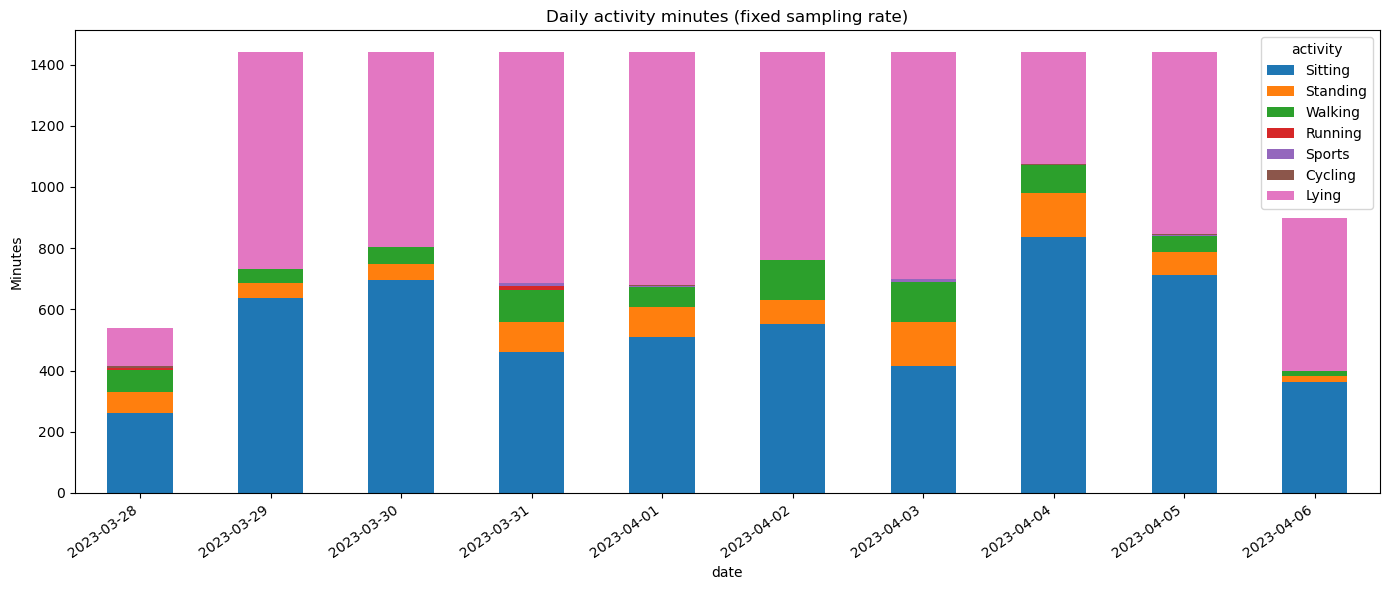

In [11]:
ACTIVITY_ORDER = ['Sitting', 'Standing', 'Walking', 'Running', 'Sports', 'Cycling','Lying']
minutes=minutes_summary(df_predicted,encoding_dict_PB,ACTIVITY_ORDER, analytics="activity", plot=True)

In [12]:
minutes = minutes.round(2)
minutes

,date,Sitting,Standing,Walking,Running,Sports,Cycling,Lying,daily_count
0,2023-03-28,262.67,66.33,73.67,4.50,2.17,4.67,126.17,540.17
1,2023-03-29,637.00,49.50,43.83,0.00,2.83,0.33,706.50,1440.00
2,2023-03-30,695.50,52.83,54.33,0.00,2.00,0.17,635.17,1440.00
3,2023-03-31,460.17,98.00,105.83,13.33,8.83,0.17,753.67,1440.00
4,2023-04-01,508.50,97.67,68.17,0.00,3.50,0.33,761.83,1440.00
5,2023-04-02,552.00,79.17,128.67,0.00,2.33,0.17,677.67,1440.00
6,2023-04-03,414.67,143.17,130.50,1.83,9.17,0.67,740.00,1440.00
7,2023-04-04,836.83,144.17,90.17,0.00,2.17,0.33,366.33,1440.00
8,2023-04-05,712.33,74.83,54.17,0.00,3.00,0.50,595.17,1440.00
9,2023-04-06,363.67,17.50,17.67,0.00,0.50,0.33,500.17,899.83


## Daily spend time in different levels of energy expenditure

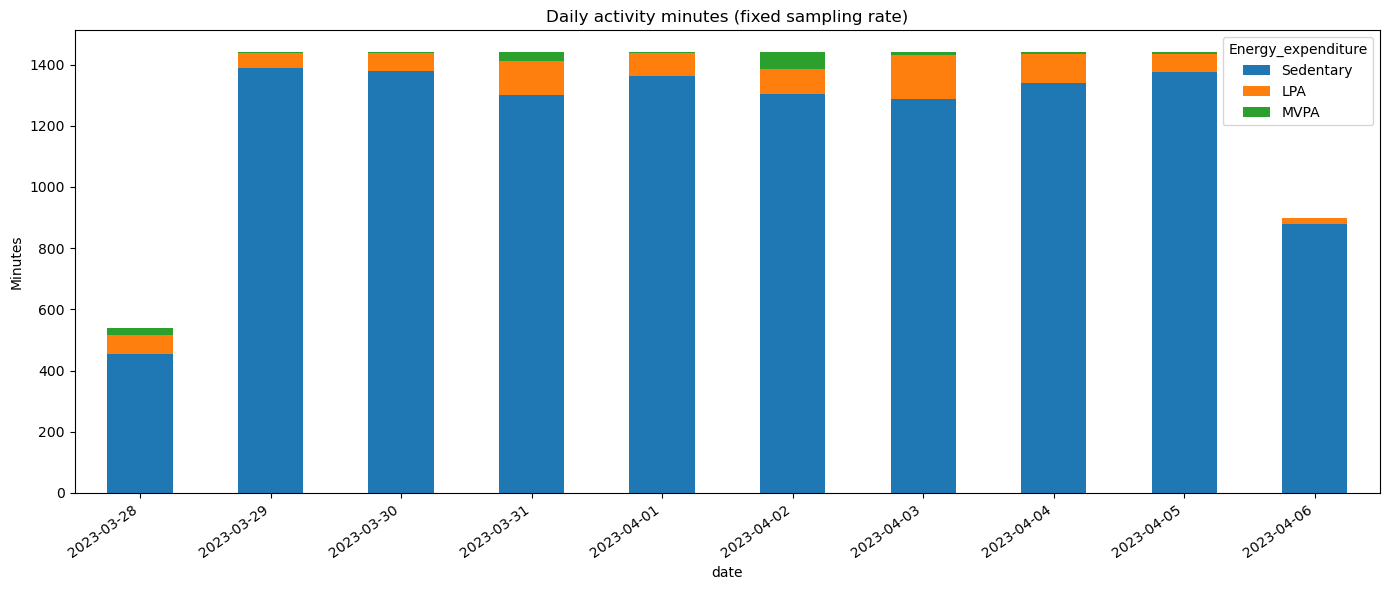

In [13]:
ACTIVITY_ORDER_EE = ['Sedentary', 'LPA', 'MVPA']
minutes_EE=minutes_summary(df_predicted,encoding_dict_EE,ACTIVITY_ORDER_EE, analytics="Energy_expenditure", plot=True)

In [14]:
minutes_EE

,date,Sedentary,LPA,MVPA,daily_count
0,2023-03-28,453.000000,61.833333,25.333333,540.166667
1,2023-03-29,1388.833333,49.166667,2.000000,1440.000000
2,2023-03-30,1378.500000,61.000000,0.500000,1440.000000
3,2023-03-31,1302.000000,111.000000,27.000000,1440.000000
4,2023-04-01,1364.333333,72.166667,3.500000,1440.000000
5,2023-04-02,1304.333333,82.666667,53.000000,1440.000000
6,2023-04-03,1287.166667,145.833333,7.000000,1440.000000
7,2023-04-04,1340.166667,94.500000,5.333333,1440.000000
8,2023-04-05,1375.833333,57.500000,6.666667,1440.000000
9,2023-04-06,878.666667,20.333333,0.833333,899.833333


# BATCH PROCESSING

## Batch Prediction


In [15]:
# Step 1 – Predic PB and EE in all files stored in an specific folder

path_AP_files ="Test_DATA_AP_AG" # Folder of activePAL files (.datx or .csv)
out = Path("Predicted_AP_AGC_CSVs")
out.mkdir(exist_ok=True)
allFiles = glob.glob(path_AP_files + "/*.datx") #Filter files with specific extension

for file_ in allFiles:
    print(file_)
    df_predicted, _ = predict_single_file_AP(file_, loaded_model,encoding_dict_PB,encoding_dict_EE,batch_size=512)
    ID_num = re.search(r'\d+', os.path.basename(file_)).group(0)#get ID number
    # Save as CSV
    df_predicted.to_csv(out / f"{ID_num}_PB_EE_predicted_7class_multitask_AP.csv", index=False)
    del df_predicted
    gc.collect()#Clear memory

Test_DATA_AP/1110-AP170015 202a 8May23 3-00pm for 9d.datx
152/152 [==============================] - 3s 20ms/step
Test_DATA_AP/1221-AP170016 202a 14Aug23 3-00pm for 9d.datx
152/152 [==============================] - 3s 19ms/step


## Compute daily spend time in PB and EE as batch process

In [16]:
# Step 2 – Compute daily spend time in PB and EE and merges the resuults in a single dataframe

path =r'Predicted_AP_AGC_CSVs' # Folder of Predicted_AP_CSVs
allFiles = glob.glob(path + "/*.csv") #Filter files with specific extension
dfs = [] #Create an empty space to store the single files results

for file_ in allFiles:
    print(file_)
    df_predicted = pd.read_csv(file_, sep=",")
    ID_num = re.search(r'\d+', os.path.basename(file_)).group(0)#get ID number
    minutes_PB=minutes_summary(df_predicted,encoding_dict_PB,ACTIVITY_ORDER,analytics="activity",plot=False)
    minutes_EE=minutes_summary(df_predicted,encoding_dict_EE,ACTIVITY_ORDER_EE, analytics="Energy_expenditure", plot=False)
    minutes_EE = minutes_EE.drop(columns=["daily_count", "date"])#remove repeated columns
    minutes_df = pd.concat([minutes_PB, minutes_EE], axis=1)
    # Insert subject ID in the first column
    minutes_df.insert(0, "ID", ID_num)
    dfs.append(minutes_df)#store partial results
    
df_all = pd.concat(dfs, ignore_index=True)#flatten all dfs in a single df

Predicted_AP_CSVs/1221_PB_EE_predicted_7class_multitask_AP.csv
Predicted_AP_CSVs/1110_PB_EE_predicted_7class_multitask_AP.csv


In [17]:
df_all = df_all.round(2)
df_all.head(12)

,ID,date,Sitting,Standing,Walking,Running,Sports,Cycling,Lying,daily_count,Sedentary,LPA,MVPA
0,1221,2023-08-14,197.83,36.17,89.17,5.33,5.83,11.00,194.83,540.17,425.17,49.33,65.67
1,1221,2023-08-15,547.33,208.33,170.83,0.17,5.00,11.17,497.17,1440.00,1234.50,128.67,76.83
2,1221,2023-08-16,592.50,148.17,143.83,0.00,4.83,39.17,511.50,1440.00,1237.67,175.83,26.50
3,1221,2023-08-17,664.83,111.50,87.00,0.33,5.17,37.00,534.17,1440.00,1289.17,134.00,16.83
4,1221,2023-08-18,777.50,88.67,105.67,0.00,5.00,0.17,463.00,1440.00,1316.17,113.50,10.33
5,1221,2023-08-19,503.00,80.33,124.50,0.00,7.00,0.50,724.67,1440.00,1292.67,131.83,15.50
6,1221,2023-08-20,557.00,61.50,86.50,58.67,5.50,0.17,670.67,1440.00,1277.00,83.83,79.17
7,1221,2023-08-21,651.17,90.33,105.33,0.00,4.67,27.67,560.83,1440.00,1281.33,128.83,29.83
8,1221,2023-08-22,623.83,118.33,96.67,39.50,6.00,23.00,532.67,1440.00,1262.33,132.67,45.00
9,1221,2023-08-23,411.50,89.00,58.83,0.00,1.00,5.33,334.17,899.83,827.67,60.67,11.50


In [18]:
# SAVE TABLE DAILY SUMMARY PER SUBJECT
#df_all.to_csv("DAILY_SUMMARY_PER_SUBJECT_TEST.csv", index=False)

## Data analytics on multiple files

In [19]:
from wealth_pb_ee_models.utils.utils_analytics import filter_valid_days,summarize_weekday_weekend_weighted, summarize_weekday_weekend
from wealth_pb_ee_models.utils.utils_analytics import plot_multiple_weighted_summaries, prepare_plot_data, plot_activity_bars

In [20]:
# Step 1 – Filter valid days per hour (≥ 8 hours)
df_valid = filter_valid_days(df_all, min_wear_hours=8)

In [21]:
# Step 2 – Summarise weekday vs weekend in a single value (WEIGTHED 2/5)
'''Summarise activity per participant using a weighted average. Weighting: Weekdays: 5/7; Weekends: 2/7'''
summary_weigthed_AP = summarize_weekday_weekend_weighted(df_valid,ACTIVITY_ORDER,ACTIVITY_ORDER_EE)
summary_weigthed_AP

,ID,Sitting_mean,Sitting_std,Standing_mean,Standing_std,Walking_mean,Walking_std,Running_mean,Running_std,Sports_mean,...,Cycling_mean,Cycling_std,Lying_mean,Lying_std,Sedentary_mean,Sedentary_std,LPA_mean,LPA_std,MVPA_mean,MVPA_std
0,1110,521.216607,159.455404,125.837679,52.373496,173.991071,82.514529,0.178571,0.285153,13.341964,...,17.313571,12.017101,459.536607,120.136492,1091.092679,221.05726,175.536964,66.053173,44.785536,23.798664
1,1221,550.222321,138.996927,99.770357,39.941870,106.690179,32.684478,12.428750,21.706078,5.133929,...,13.891250,10.480683,523.293214,100.777703,1159.418036,230.27596,113.263929,39.292240,38.746607,30.729830


## Averaged daily distribution of time spent in PB (Weighted summaries) 

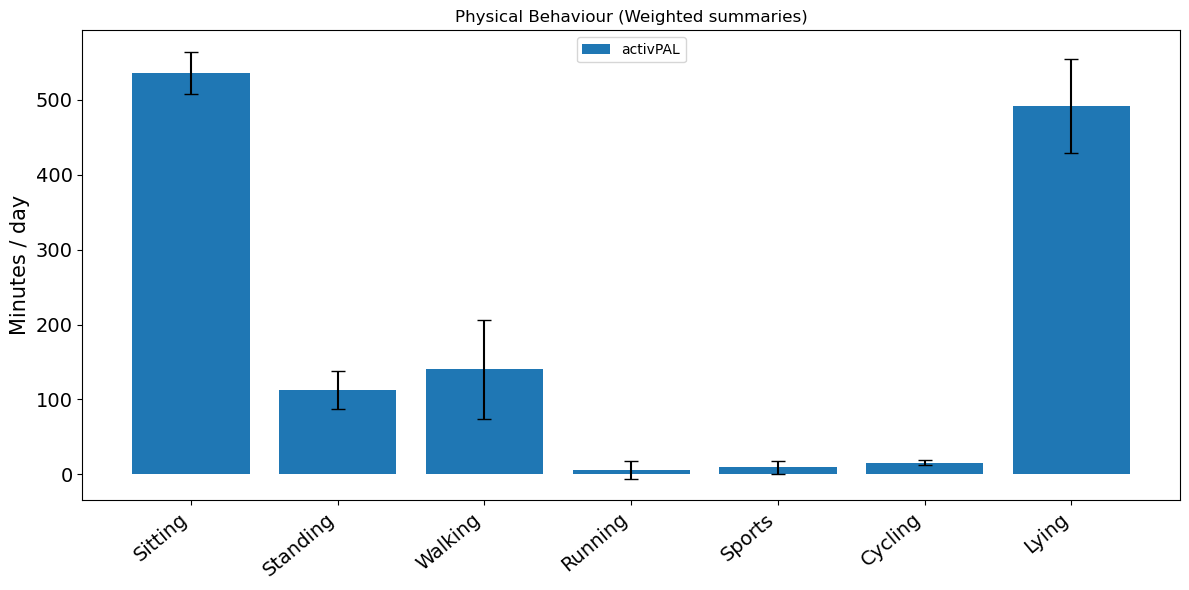

In [22]:
plot_multiple_weighted_summaries(
    summaries={ "Dual-Sensor":summary_weigthed_AP},
    variables=ACTIVITY_ORDER, title="Physical Behaviour (Weighted summaries)")

## Averaged daily distribution of time spent in EE (Weighted summaries) 

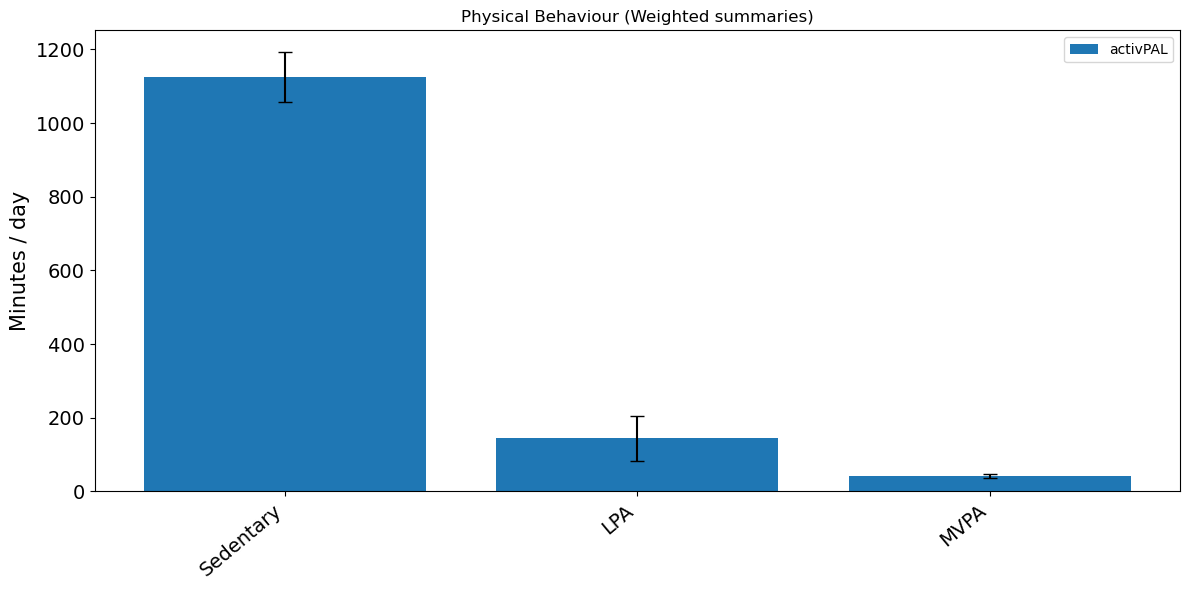

In [23]:
plot_multiple_weighted_summaries(
    summaries={ "Dual-Sensor":summary_weigthed_AP },
    variables=ACTIVITY_ORDER_EE, title="Physical Behaviour (Weighted summaries)")